### Code for sanity checking data from sub1

In [23]:
#Load packagaes
import mne
import matplotlib_inline
import matplotlib.pyplot as plt
import os
import numpy as np
import os.path as op
import warnings
import inspect
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
)

warnings.filterwarnings('ignore')

file path structure: <BIDS_ROOT>/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif

/Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif

In [50]:
subject = '01'  
session = '01'  
task = 'face'
run = '01'  
meg_suffix = 'meg'
meg_extension = '.fif'
events_suffix = 'events'
events_extension = '.tsv'

# data_path='/Users/rekaforgo/Documents/Bachelor2025'
data_path = '/Users/rekaforgo/Documents/Bachelor2025'


bids_path = BIDSPath(subject=subject, session=session,
                     task=task, run=run, suffix=meg_suffix, 
                     extension=meg_extension, root=data_path)



In [51]:
print(bids_path)


# Read the raw data
raw = read_raw_bids(bids_path=bids_path, 
                    verbose=False,
                    extra_params={'preload': True})

/Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/sub-01_ses-01_task-face_run-01_meg.fif


In [52]:
print(raw)

<Raw | SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif, 65 x 325340 (325.3 s), ~161.4 MiB, data loaded>


In [53]:
print(raw.info)

<Info | 12 non-empty values
 bads: []
 ch_names: MEG01, MEG02, MEG03, MEG04, MEG05, MEG06, MEG07, MEG08, MEG09, ...
 chs: 64 Magnetometers, 1 Stimulus
 custom_ref_applied: False
 experimenter: PKU XU WEI
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: sub-01, sex: 1, hand: 1>
>


In [16]:
ch_names = raw.info['ch_names']
print(ch_names)

['MEG01', 'MEG02', 'MEG03', 'MEG04', 'MEG05', 'MEG06', 'MEG07', 'MEG08', 'MEG09', 'MEG10', 'MEG11', 'MEG12', 'MEG13', 'MEG14', 'MEG15', 'MEG16', 'MEG17', 'MEG18', 'MEG19', 'MEG20', 'MEG21', 'MEG22', 'MEG23', 'MEG24', 'MEG25', 'MEG26', 'MEG27', 'MEG28', 'MEG29', 'MEG30', 'MEG31', 'MEG32', 'MEG33', 'MEG34', 'MEG35', 'MEG36', 'MEG37', 'MEG38', 'MEG39', 'MEG40', 'MEG41', 'MEG42', 'MEG43', 'MEG44', 'MEG45', 'MEG46', 'MEG47', 'MEG48', 'MEG49', 'MEG50', 'MEG51', 'MEG52', 'MEG53', 'MEG54', 'MEG55', 'MEG56', 'MEG57', 'MEG58', 'MEG59', 'MEG60', 'MEG61', 'MEG62', 'MEG63', 'MEG64', 'STIM']


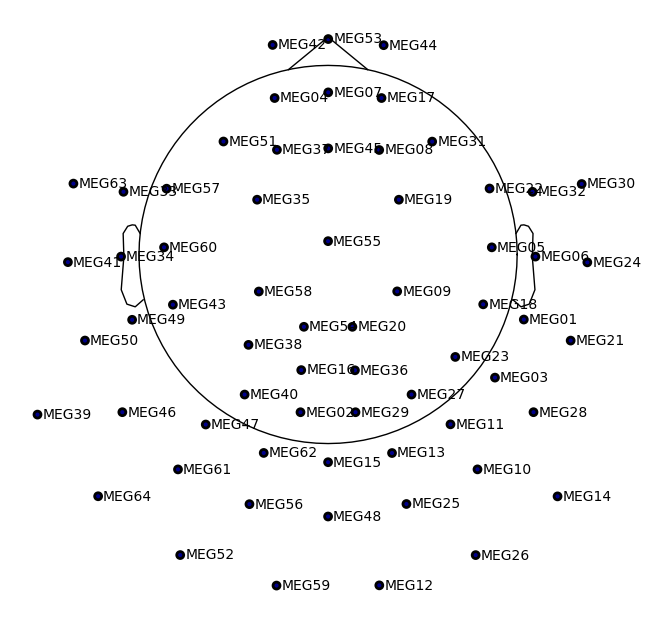

In [17]:
raw.plot_sensors(kind='topomap', show_names=True);

In [70]:
raw.plot(
    picks='mag',
    duration=5,
    proj=False,
    scalings=dict(mag= 1e-9)   # 5 nT
);

Channels marked as bad:
none


In [ ]:
for ch in mne.pick_types(raw.info, meg=True, stim=False):
    raw.info['chs'][ch]['unit'] = mne.io.constants.FIFF.FIFF_UNIT_T
    raw.info['chs'][ch]['unit_mul'] = 0


Channels marked as bad:
none
Channels marked as bad:
none


Note that in the FLUX pipeline they calculate the power spectra for only one dimension of sensors. Their sensors are named OPM *X* OPM *Y* and OPM *Z* based on the dimension. They say it is easier to compute PSD for the Z dimension. Plus they also mark the bad channels.

In [74]:
picks = mne.pick_types(raw.info, meg=True, eeg=False, eog=False, stim=False, exclude='bads')

n_fft = 2000 # achieving a 0.5 Hz frequency resolution
raw_psd = raw.compute_psd('welch', fmin=0.0, fmax=120, picks=picks, n_fft=n_fft, n_overlap=int(n_fft // 2))

Effective window size : 2.000 (s)


Note the 50 Hz line noise. The frequency of the line noise is 50 Hz in European countries including Russia as well as Asian countries including India and China. It is 60 in South Korea as well as South and North America. In Japan it will be either 50 or 60 Hz depending on the region.

In [76]:
%matplotlib qt
raw_psd.plot(exclude='bads',picks='mag');

Plotting power spectral density (dB=True).


In [77]:
%matplotlib qt
raw.plot(duration=10, title='Raw', picks=picks);

Channels marked as bad:
none
